In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import joblib

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw,integrated_brier_score

Overall goal: in building a predictive model, we want to successfully predict a hospital closure with enough lead time before it occurs to give the hospital sufficient leeway to make the necessary changes to stay open.

Reading in the full dataset, splitting out columns into categories, and dropping columns that are not needed to create the dataset I'll use for the model:

In [2]:
hospitals_full = pd.read_csv('../data/hospitals_full.csv')

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_77387/3201850437.py:1: DtypeWarning: Columns (67) have mixed types. Specify dtype option on import or set low_memory=False.
  hospitals_full = pd.read_csv('../data/hospitals_full.csv')


In [3]:
model_data = hospitals_full.drop(columns=['State', 'Zip', 'County','Facility Name','Closed', 'Closure Date','Full Address', 'Prior Name','Tract_Code', 'CBSA_Code', 'CBSA_Title','County_FIPS', 'State_FIPS'])


In [4]:
model_data.shape

(13421, 190)

In [5]:
model_data.head()

,Year,CCN,Medicaid charges,HAC reduction adjustment amount,STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29),"ADJUSTED SALARIES, Subtotal Salaries",BALANCE SHEET: Prepaid expenses (G_C1THRU4_8),BED DAYS: Total Hospital,Number of Interns & Residents,BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1),...,Per Capita Short Term Gen Hosp Admissions,Per Capita Short Term General Hosp Beds,Per Capita Total Active D.O.s Non-Federal,Per Capita Total Active M.D.s Non-Federal,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,Per Capita Total Number Hospitals,Percent Persons in Poverty,Population Estimate,"Unemployment Rate, 16+",Time
0,2010,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.092921,0.003529,0.0,0.000664,0.241335,0.000065,21.0,61773.0,6.8,15
1,2011,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.085783,0.003275,0.0,0.000710,0.230389,0.000065,22.4,61982.0,6.3,15
2,2012,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.083247,0.003279,0.0,0.000695,0.244573,0.000065,20.7,61912.0,5.6,15
3,2013,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.082776,0.003263,0.0,0.000675,0.262877,0.000064,19.0,62204.0,NaN,15
4,2014,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.082386,0.003249,0.0,0.000736,0.269148,0.000048,22.0,62486.0,5.7,15


In [6]:
print(list(model_data.columns))

['Year', 'CCN', 'Medicaid charges', 'HAC reduction adjustment amount', 'STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29)', 'ADJUSTED SALARIES, Subtotal Salaries', 'BALANCE SHEET: Prepaid expenses (G_C1THRU4_8)', 'BED DAYS: Total Hospital', 'Number of Interns & Residents', 'BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)', 'Cost To Charge Ratio', 'Total discharges', 'REIMBURSEMENT SETTLEMENT: Payment to cost ratio', 'Cost of Uncompensated Care', 'BALANCE SHEET: Accounts Receivable (G_C1THRU4_4)', 'Total Salaries', 'BALANCE SHEET: Total Assets (G_C1THRU4_36)', 'BALANCE SHEET: Total Current Assets (G_C1THRU4_11)', 'REIMBURSEMENT SETTLEMENT: Interim payments', 'Total Bad Debt expense', 'TRIAL BALANCE OF EXPENSE ACCOUNTS: Interest Expense (A_C2_113)', 'NUMBER OF BEDS: Adults & Pediatrics', 'BALANCE SHEET: Temporary Investments (G_C1THRU4_2)', 'NUMBER OF BEDS: Total Hospital', 'Total Inpatient Days', 'Total Days Title XVIII', 'Total cost of charity care', 'Total Costs', 'NUMB

#### Exploratory Data Analysis:

How are hospital closures distributed across the years?

In [7]:
hospitals_full['Closure Date'] = pd.to_datetime(hospitals_full['Closure Date'])

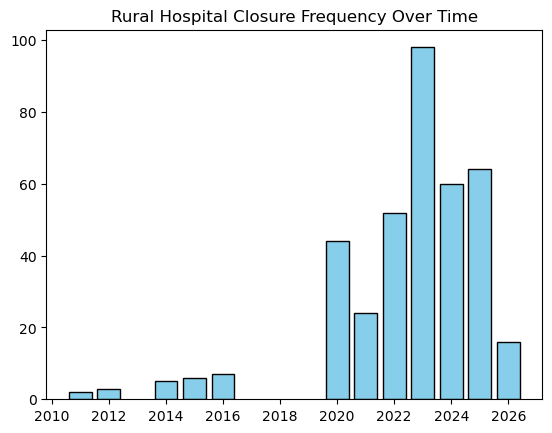

In [8]:
closures = hospitals_full[~hospitals_full['Closure Date'].isna()]

years = closures['Closure Date'].apply(lambda x: x.year)

# Count the frequency of each year
year_counts = Counter(list(closures['Closure Date'].apply(lambda x: x.year)))

# Sort by year so the x-axis is chronological
sorted_years = sorted(year_counts.keys())
frequencies = [year_counts[year] for year in sorted_years]

# Create the plot
plt.bar(sorted_years, frequencies, color='skyblue', edgecolor='black');
plt.title('Rural Hospital Closure Frequency Over Time');
plt.savefig("../app/images/closure_plot.png")

Seeing if there is a trend with missing value frequency over time.

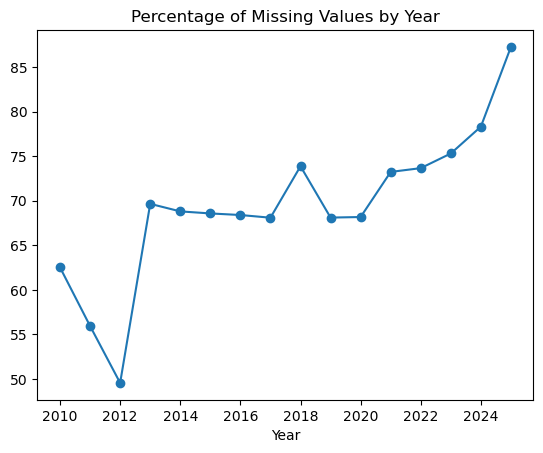

In [9]:
years = model_data['Year']
nan_percentages_all = model_data.drop(columns=['Year']).isna().groupby(years).mean() * 100
nan_percentages = nan_percentages_all.mean(axis=1)
nan_percentages.plot(kind='line',marker='o')
plt.title('Percentage of Missing Values by Year');

Looking at percentage of NaN values per year for a single column per feature type (financial, quality, demographic)

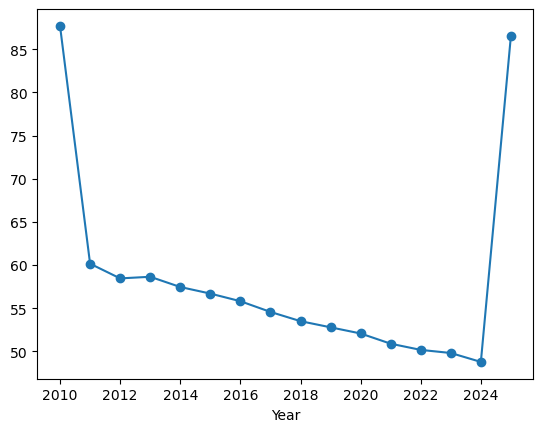

In [10]:
(model_data.groupby('Year')['Financial Indicators: Cash Reserves'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

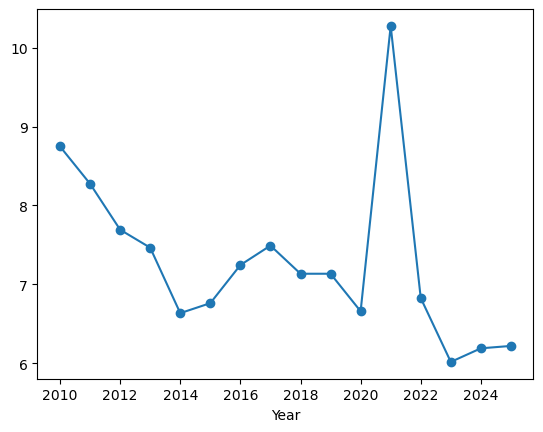

In [11]:
(model_data.groupby('Year')['clean_score'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

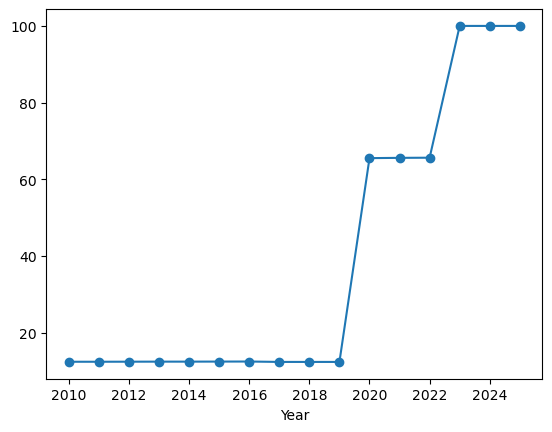

In [12]:
(model_data.groupby('Year')['% <65 without Health Insurance'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

In [13]:
model_data[model_data['Year']>=2022].isna().mean().sort_values(ascending=False)

scipinf6_denom        1.0
ami8_share            1.0
op6_share             1.0
ami10_denom           1.0
op1_denom             1.0
                     ... 
Status                0.0
Metro_Status          0.0
RUCA                  0.0
Emergency Services    0.0
Time                  0.0
Length: 190, dtype: float64

In [14]:
model_data[model_data['Year']<2022].isna().mean().sort_values(ascending=False)

hf_readm_npatients    1.0
hk_readm_npatients    1.0
ami_mort_rate         1.0
ami_readm_rate        1.0
hf_mort_rate          1.0
                     ... 
Status                0.0
Metro_Status          0.0
RUCA                  0.0
Emergency Services    0.0
Time                  0.0
Length: 190, dtype: float64

#### Feature Engineering:

Creating "General Ownership" column to group hospital types into 'govt','non-profit', and 'for-profit':

In [15]:
model_data['Hospital Type'] = model_data['Hospital Type'].replace('Governmental, Federal', 'Government - Federal')

In [16]:
model_data['General Ownership Type'] = model_data['Hospital Type'].replace({'Voluntary non-profit - Other': 'non-profit',
                                            'Voluntary non-profit - Private': 'non-profit',
                                           'Voluntary non-profit - Church': 'non-profit',
                                           'Government - State': 'govt',
                                           'Government - Local': 'govt', 
                                           'Government - Hospital District or Authority': 'govt', 
                                           'Government - Federal': 'govt', 
                                           'Governmental, Other': 'govt',
                                           'Proprietary, Corporation': 'for-profit', 
                                           'Proprietary': 'for-profit', 
                                           'Tribal': 'govt',
                                           'Physician': 'for-profit',
                                           'Non profit - Corporation': 'non-profit'
                                          }, 
                                         )

In [17]:
model_data['General Ownership Type'].isna().sum()

np.int64(0)

In [18]:
model_data['Hospital Type'].nunique()

13

In [19]:
pd.set_option('display.max_rows', None)
model_data.isnull().mean().sort_values(ascending=False)

hf_readm_npatients                                                         1.000000
ami_readm_rate                                                             1.000000
hf_readm_rate                                                              1.000000
pn_mort_rate                                                               1.000000
pn_readm_rate                                                              1.000000
ami_mort_npatients                                                         1.000000
ami_readm_npatients                                                        1.000000
hf_mort_npatients                                                          1.000000
ami_mort_rate                                                              1.000000
pn_mort_npatients                                                          1.000000
pn_readm_npatients                                                         1.000000
all_readm_rate                                                             1

In [20]:
# Drop columns that are more than 80% NaNs
model_data = model_data.loc[:, model_data.isnull().mean() <= 0.80]

In [21]:
model_data.shape

(13421, 95)

This still leaves us with 92 features (94 columns minus CCN and target column)

Breaking down features into large scale types:

In [22]:
id_cols = ['Year','CCN']
target_cols = ['Status','Time']
hospital_char_cols = ['General Ownership Type','Emergency Services','Hospital Type']
financial_cols = ['BALANCE SHEET: Total Assets (G_C1THRU4_36)', 'BED DAYS: Total Hospital', 'REIMBURSEMENT SETTLEMENT: Interim payments', 
                  'IPPS Interim payment', 'BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)', 
                  'BALANCE SHEET: Total Current Liabilities (G_C1THRU4_45)', 'Total cost of charity care', 
                  'HVBP payment adjustment amount', 'Total discharges', 'Total Salaries', 
                  'BALANCE SHEET: Accounts Receivable (G_C1THRU4_4)', 'Net Revenue from Medicaid', 
                  'Total Bad Debt expense', 'Total Charges', 'ADJUSTED SALARIES, Subtotal Salaries', 
                  'NUMBER OF BEDS: Adults & Pediatrics', 'Total Costs', 'BALANCE SHEET: Prepaid expenses (G_C1THRU4_8)', 
                  'BALANCE SHEET: Total Current Assets (G_C1THRU4_11)', 'Cost To Charge Ratio', 'REIMBURSEMENT SETTLEMENT: Subtotal', 
                  'Number of Interns & Residents', 'RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)', 
                  'Total Inpatient Days', 'STATEMENT OF REVENUES AND EXPENSES: Net Patient Revenue (G3_C1_3)', 
                  'NUMBER OF BEDS: Total Hospital', 'NUMBER OF BEDS: ICU', 'STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29)', 
                  'BALANCE SHEET: Inventory (G_C1THRU4_7)', 'IPPS Payment amount (unadjusted)', 
                  'TRIAL BALANCE OF EXPENSE ACCOUNTS: Interest Expense (A_C2_113)', 'Cost of Uncompensated Care', 'Medicaid charges', 
                  'Total Liabilities', 'Total Days Title XVIII', 'Financial Indicators: Total Net Assets', 'S-10 DATA: Medicaid Costs', 
                  'Financial Indicators: Cash Reserves', 'Financial Indicators: Net Profit Margin', 'Financial Indicators: Operating Profit', 
                  'Financial Indicators: Operating Profit Margin', 'Financial Indicators: LIQUIDITY current ratio', 
                  'Financial Indicators: LIQUIDITY acid-test ratio', 'Financial Indicators: LIQUIDITY acid-test ratio (variation)', 
                  'Financial Indicators: LIQUIDITY cash ratio', 'Financial Indicators: SOLVENCY Debt-to-Equity Ratio', 
                  'Financial Indicators: SOLVENCY Debt Ratio', 'Financial Indicators: SOLVENCY Equity Ratio', 
                  'Financial Indicators: SOLVENCY Interest Coverage Ratio', 'Financial Indicators: SOLVENCY total assets less total liabilities', 
                  'Financial Indicators: EFFICIENCY asset turnover ratio', 'Financial Indicators: EFFICIENCY Accounts Receivable Turnover Ratio']
hosp_quality_cols = ['nsurveys', 'rrate', 'clean_score', 'commdoc_score', 'commnurse_score', 'explain_score', 'help_score', 
                     'info_score', 'overall_score', 'pain_score', 'quiet_score', 'recommend_score', 'understood_score']
demographic_cols = ['RUCA','Metro_Status','% <65 without Health Insurance', 'Dist Hosp By 00 - 39% Util Rate Short Term General Hospitals', 
                    'Dist Hosp By 40 - 59% Util Rate Short Term General Hospitals', 
                    'Dist Hosp By 60 - 79% Util Rate Short Term General Hospitals', 
                    'Dist Hosp By 80+% Util Rate Short Term General Hospitals', 
                    'Median Household Income', 'Per Capita # Short Term General Hosps', 'Per Capita Hospital Admissions', 
                    'Per Capita Hospital Beds', 'Per Capita Inpatient Days in ST Gen Hosp', 'Per Capita Personal Income', 
                    'Per Capita Phys,Primary Care, Patient Care Non-Fed', 'Per Capita Short Term Gen Hosp Admissions', 
                    'Per Capita Short Term General Hosp Beds', 'Per Capita Total Active D.O.s Non-Federal', 
                    'Per Capita Total Active M.D.s Non-Federal', 'Per Capita Total Medicare Inpatient Days Short Term General Hospitals', 
                    'Per Capita Total Number Hospitals', 'Percent Persons in Poverty', 'Population Estimate', 'Unemployment Rate, 16+']



Looking at distributions of numeric features to see what type of imputation is appropriate:

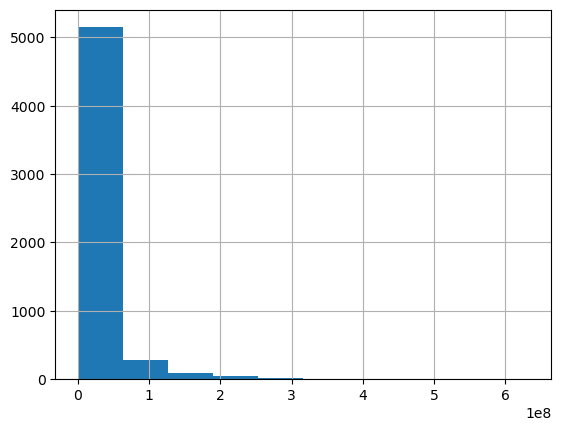

In [23]:
model_data['Financial Indicators: Cash Reserves'].hist();

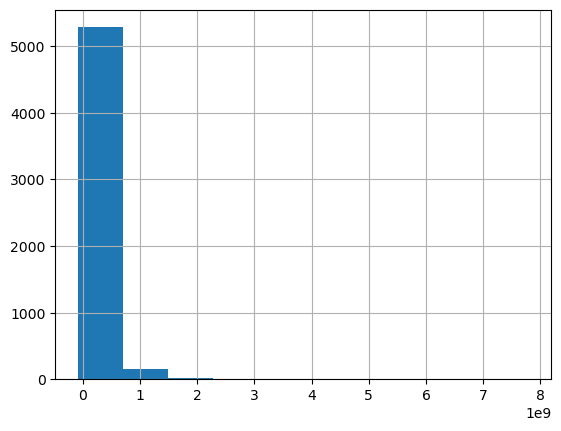

In [24]:
model_data['BALANCE SHEET: Total Assets (G_C1THRU4_36)'].hist();

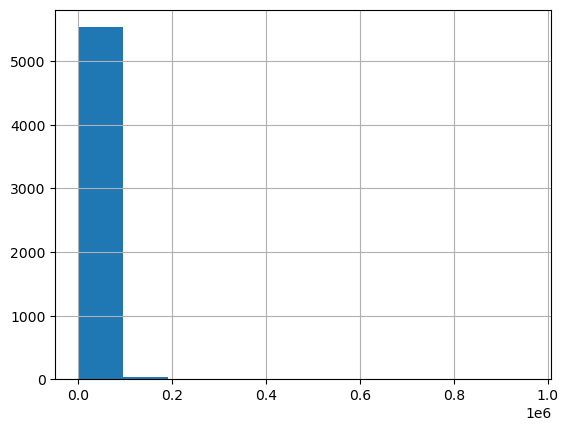

In [25]:
model_data['Total Inpatient Days'].hist();

The numeric variables seem to be very right skewed, so a median imputation would be appropriate.

Are there any hospitals that we don't have any data for?

In [26]:
model_data[model_data[financial_cols + hosp_quality_cols + demographic_cols].isna().all(axis=1)]

,Year,CCN,Medicaid charges,STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29),"ADJUSTED SALARIES, Subtotal Salaries",BALANCE SHEET: Prepaid expenses (G_C1THRU4_8),BED DAYS: Total Hospital,Number of Interns & Residents,BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1),Cost To Charge Ratio,...,Per Capita Short Term General Hosp Beds,Per Capita Total Active D.O.s Non-Federal,Per Capita Total Active M.D.s Non-Federal,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,Per Capita Total Number Hospitals,Percent Persons in Poverty,Population Estimate,"Unemployment Rate, 16+",Time,General Ownership Type


For every hospital in the dataset, we have at least some financial data, quality data, and/or demographic data.

Ensuring all of the data types are appropriate for the values they represent:

In [27]:
model_data.dtypes

Year                                                                         int64
CCN                                                                          int64
Medicaid charges                                                           float64
STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29)                  float64
ADJUSTED SALARIES, Subtotal Salaries                                       float64
BALANCE SHEET: Prepaid expenses (G_C1THRU4_8)                              float64
BED DAYS: Total Hospital                                                   float64
Number of Interns & Residents                                              float64
BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)                     float64
Cost To Charge Ratio                                                       float64
Total discharges                                                           float64
Cost of Uncompensated Care                                                 float64
BALA

In [28]:
model_data['RUCA'] = model_data['RUCA'].astype(object)

#### Data Preprocessing:

In [29]:
numeric_features = [col for col in model_data.select_dtypes('number').columns if col not in ['CCN','Status','Time','Year']]


In [30]:
categorical_features = [col for col in model_data.select_dtypes('object').columns]

In [31]:
numeric_features

['Medicaid charges',
 'STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29)',
 'ADJUSTED SALARIES, Subtotal Salaries',
 'BALANCE SHEET: Prepaid expenses (G_C1THRU4_8)',
 'BED DAYS: Total Hospital',
 'Number of Interns & Residents',
 'BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)',
 'Cost To Charge Ratio',
 'Total discharges',
 'Cost of Uncompensated Care',
 'BALANCE SHEET: Accounts Receivable (G_C1THRU4_4)',
 'Total Salaries',
 'BALANCE SHEET: Total Assets (G_C1THRU4_36)',
 'BALANCE SHEET: Total Current Assets (G_C1THRU4_11)',
 'REIMBURSEMENT SETTLEMENT: Interim payments',
 'Total Bad Debt expense',
 'TRIAL BALANCE OF EXPENSE ACCOUNTS: Interest Expense (A_C2_113)',
 'NUMBER OF BEDS: Adults & Pediatrics',
 'NUMBER OF BEDS: Total Hospital',
 'Total Inpatient Days',
 'Total Days Title XVIII',
 'Total cost of charity care',
 'Total Costs',
 'NUMBER OF BEDS: ICU',
 'Total Charges',
 'Net Revenue from Medicaid',
 'Total Liabilities',
 'HVBP payment adjustment amount',
 'REIMBUR

Casting inf values to NaN:

In [32]:
model_data = model_data.replace([np.inf, -np.inf], np.nan)

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_77387/1911048971.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_data = model_data.replace([np.inf, -np.inf], np.nan)


In [33]:
model_data[categorical_features].isnull().mean().sort_values(ascending=False)

Emergency Services        0.0
RUCA                      0.0
Metro_Status              0.0
Hospital Type             0.0
General Ownership Type    0.0
dtype: float64

None of our categorical variables have missing values, so we don't need to worry about imputing them.

#### Train/test split:

Since there are 16 years in our dataset, we'll reserve 2022-2025 as our real-world test data to achieve a 75%/25% train/test split

In [34]:
cutoff = 2022
train = model_data[model_data['Year'] < cutoff]
test = model_data[model_data['Year'] >= cutoff]

In [35]:
# Write the unscaled training data to a pkl file to be used by the Streamlit app 
train.to_pickle('../app/data/train_unscaled.pkl')

In [36]:
train["Hospital Type"].sort_values().unique()

array(['Government - Federal',
       'Government - Hospital District or Authority',
       'Government - Local', 'Government - State', 'Governmental, Other',
       'Non profit - Corporation', 'Physician', 'Proprietary',
       'Proprietary, Corporation', 'Tribal',
       'Voluntary non-profit - Church', 'Voluntary non-profit - Other',
       'Voluntary non-profit - Private'], dtype=object)

#### Building a preprocessing pipeline:

In [37]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
    # Tried applying an iterative imputer to fill missing values, 
    # but it repeatedly did not converge on the train data, which means it definitely would not converge on the test data (more missing values)
    ("imputer", SimpleImputer(strategy='median'))
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all the transformations into 1 preprocessor
# Using ColumnTransformer to select specific columns and apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

pipe = Pipeline(
    steps=[("preprocessor", preprocessor)]
)

#### Hyperparameter Tuning using a validation set:

Here, we'll split our data using k-fold validation and apply the pre-processor pipeline (scaling and filling in missing values). 

Once we have our pre-processed cross-validation datasets, we'll fit a model to each of the training sets and evaluate its effectiveness via the corresponding validation set. 

Below is the survival regression model I'll use to predict hospital closures. 

In [38]:
# Ensure the train set is sorted by year to prevent data leakage during train/validation split
test = test.sort_values(by='Year')

In [39]:
# Initialize TimeSeriesSplit with 5 folds (4 splits)
k = 4
tscv = TimeSeriesSplit(n_splits=k)

# Initialize a dataframe to store model evaluation metrics
model_evaluation_results = pd.DataFrame(columns=['fold', 'l1_ratio', 'c-index'])

# Define feature columns
feature_cols = [col for col in test.columns if col not in ['CCN','Status','Time','Year']]

# Define the l1_ratio values to test
l1_ratios_to_test = [0.1, 0.5, 0.9, 1.0]

# The split() method generates indices for train/val sets
for fold, (train_index, val_index) in enumerate(tscv.split(test)):
    
    # Extract sets based on temporal indices
    train_set = test.iloc[train_index]
    val_set = test.iloc[val_index]
    
    # Split features and target
    X_train = train_set[feature_cols]
    y_train = Surv.from_arrays(train_set['Status'], train_set['Time'])
    
    X_val = val_set[feature_cols]
    y_val = Surv.from_arrays(val_set['Status'], val_set['Time'])
    
    # Preprocessing: Fit and transform the train set
    X_train_transformed = pipe.fit_transform(X_train)
    # Preprocessing: Transform the validation set
    X_val_transformed = pipe.transform(X_val)
    
    # Iterate over multiple values of l1_ratio
    for ratio in l1_ratios_to_test:
        
        # Fit penalized Cox model
        # Bumping up the alpha_min_ratio a bit from the default of 0.01 so that we limit the number of features more aggressively
        model = CoxnetSurvivalAnalysis(l1_ratio=ratio, fit_baseline_model=True, alpha_min_ratio=0.015).fit(X_train_transformed, y_train)

        # Generate predictions on the validation set and score
        y_pred = model.predict(X_val_transformed)

        # Hospitals in the validation data can't survive beyond the longest observed time in the training data, otherwise censoring probability drops to 0.0
        # Truncating validation times to max observed time in the training data
        max_train_time = train_set['Time'].max()
        y_val = Surv.from_arrays(val_set['Status'], np.minimum(val_set['Time'], max_train_time-1e-5))

        cindex_ipcw = concordance_index_ipcw(
            survival_train=y_train,
            survival_test=y_val,
            estimate=y_pred
        )
        
        # Append 1 row per combination of fold and l1_ratio
        model_evaluation_results.loc[len(model_evaluation_results)] = [fold + 1, ratio, cindex_ipcw[0]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [27 61]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [27 61]. At least one non-missing value is needed for imputation with strategy='median'.


Since the data has a high rate of censoring (hospitals not closing within the time frame of our data), Harrell's estimator (the typical concordance index computed by model.score) can be overly optimistic. I will use Uno's concordance index instead, which uses Inverse Probability of Censoring Weights (IPCW).

In [40]:
model_evaluation_results.groupby('l1_ratio')['c-index'].mean()

l1_ratio
0.1    0.670153
0.5    0.650887
0.9    0.616926
1.0    0.607076
Name: c-index, dtype: float64

Looks like l1_ratio=0.1 results in the highest c-index score, so we'll use that in the final model.

In [41]:
model_evaluation_results[model_evaluation_results['l1_ratio']==0.1][['fold','c-index']]

,fold,c-index
0,1.0,0.353780
4,2.0,0.768663
8,3.0,0.749368
12,4.0,0.808801


The concordance scores on each fold steadily trend upwards, showing the model is learning each time we add more data. This is a good sign that the model will generalize decently well to unseen data.

In [42]:
# Re-fit the model on all training data and evaluate on test data
cutoff = 2022
train = model_data[model_data['Year'] < cutoff]
test = model_data[model_data['Year'] >= cutoff]

# Define feature columns
feature_cols = [col for col in test.columns if col not in ('CCN','Status','Time','Year')]

# Split features and target
X_train = train[feature_cols]
y_train = Surv.from_arrays(train['Status'], train['Time'])

X_test = test[feature_cols]
y_test = Surv.from_arrays(test['Status'], test['Time'])

# Fit and transform the train set using our preprocessing pipeline
X_train_transformed = pipe.fit_transform(X_train)

# Save the fit preprocessing pipeline for use in the streamlit app
joblib.dump(pipe, "../app/data/preprocessor.pkl")

# Save the transformed train set to be used in the explainability notebook
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
train_df.to_csv('../data/train_set.csv', index=False)
train_df.to_pickle('../app/data/train_scaled.pkl')

# Transform the test set
X_test_transformed = pipe.transform(X_test)

# Fit penalized Cox model
# Using a CoxnetSurvivalAnalysis over a CoxPHSurvivalAnalysis model since it deals with correlated features and regularization better
model = CoxnetSurvivalAnalysis(l1_ratio=0.1, fit_baseline_model=True, alpha_min_ratio=0.015).fit(X_train_transformed, y_train)

# Generate predictions
y_pred = model.predict(X_test_transformed)

In [43]:
# Hospitals in the validation data can't survive beyond the longest observed time in the training data, otherwise censoring probability drops to 0.0
# Truncating validation times to max observed time in the training data
max_train_time = train['Time'].max()
y_test = Surv.from_arrays(test['Status'], np.minimum(test['Time'], max_train_time-1e-5))
                                 
cindex_ipcw = concordance_index_ipcw(
            survival_train=y_train,
            survival_test=y_test,
            estimate=y_pred
        )
print(f"Uno's c-index score for real-world test data: {round(cindex_ipcw[0],3)}")        

Uno's c-index score for real-world test data: 0.772


In [44]:
# Predict the survival function for the test data
# Survival function changes dynamically over time, providing the exact chronological probability of hospital closure up to a given year
surv_functions = model.predict_survival_function(X_test_transformed)

# Get unique event times from the survival functions
times = test['Time'].unique()
# Model requires the evaluation times to be completely enclosed by the time points present in the test data
# Filtering times to remove the largest time value
times = times[times != 15]

# Create a DataFrame where each row is a hospital-year and each column is a time point
surv_df = pd.DataFrame(
    np.array([fn(times) for fn in surv_functions]),
    columns=times
)

surv_df.to_csv('../data/surv_functions.csv', index=False)

In [45]:
preds = np.asarray([[fn(t) for t in times] for fn in surv_functions])

# Compute Brier Score 
brier_score = integrated_brier_score(y_train, y_test, preds, times)


In [46]:
brier_score

np.float64(0.003132046642857654)

Such a low score indicates that the model's predicted probabilities mirror the actual probability of hospital closure very well. 

However, the class imbalance could be a contributing factor here; if the model predicts a 0% chance of closure for every hospital, we will get an integrated Brier score very close to 0. 

We'd need to check the model's IBS against a Kaplan-Meier baseline model to see if this is the case. If the baseline model also achieves a similar score, the model is not actually learning complex patterns, it is just benefiting from the mathematical scarcity of the event.

In [47]:
# Append predictions to test dataframe 
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()
evaluation_df = pd.DataFrame(X_test_transformed, columns=feature_names)
evaluation_df['Pred_Closure'] = y_pred
evaluation_df['Status'] = test['Status'].values
evaluation_df['Time'] = test['Time'].values
evaluation_df['CCN'] = test['CCN'].values
evaluation_df['Year'] = test['Year'].values

# Save test set with model predictions appended to it to be used in the explainability notebook and the Streamlit app
evaluation_df.to_csv('../data/test_data_with_pred.csv', index=False)
evaluation_df.to_pickle('../app/data/test_data_with_pred.pkl')


In [48]:
# Save the model to be used in the Streamlit app 
joblib.dump(model, "../app/data/hospital_closure_model.pkl")

['../app/data/hospital_closure_model.pkl']